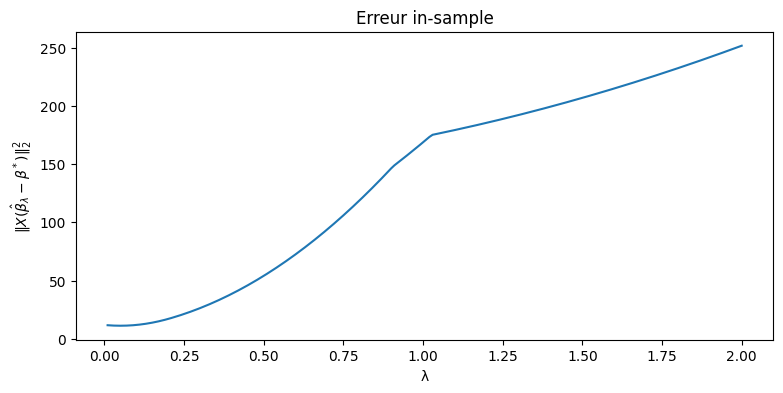

λ optimal (in-sample) = 0.05


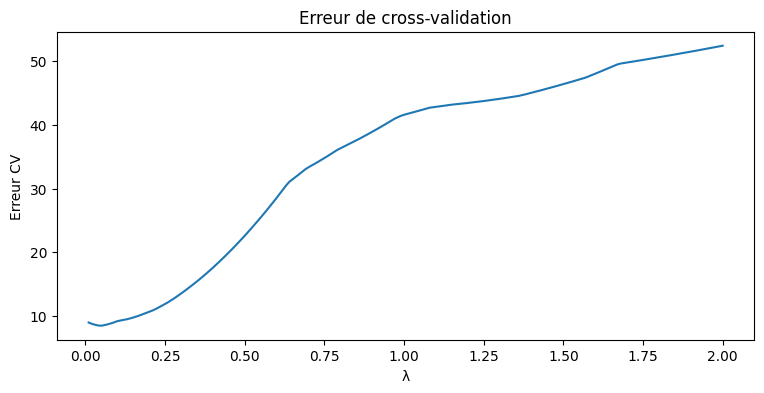

λ optimal (Cross-Validation) = 0.05
λ optimal (in-sample) = 0.05


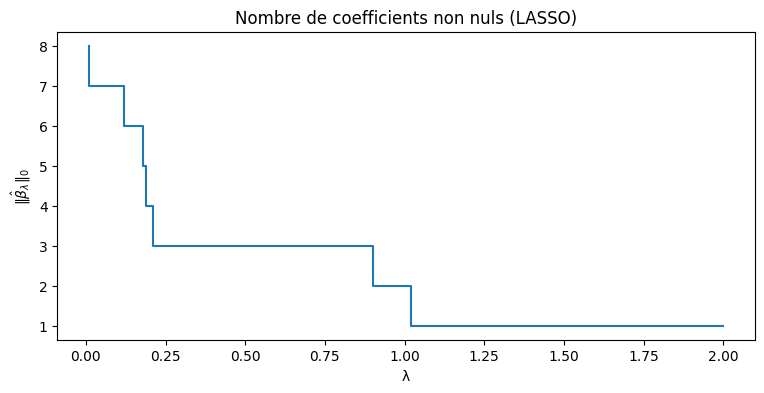

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold

# Question 1
np.random.seed(42)
n_samples = 20
dim = 8
X = np.random.standard_normal((n_samples, dim))
beta_star = np.array([5, 3, 0, 0, 1.5, 0, 0, 0])
eps = np.random.standard_normal(n_samples)
Y = X @ beta_star + eps

lam_grid = np.arange(0.01, 2.01, 0.01)

# Question 2
def lasso_fit(X, Y, lam):
    # alpha = lam / (2*n) dans sklearn (convention)
    #model = Lasso(alpha=lam / (2 * len(Y)), fit_intercept=False, max_iter=10000)
    model = Lasso(alpha=lam, fit_intercept=False, max_iter=10000)
    model.fit(X, Y)
    return model.coef_

err_lam = np.array([
    np.linalg.norm(X @ (lasso_fit(X, Y, lam) - beta_star))**2
    for lam in lam_grid
])

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, err_lam)
plt.xlabel("λ")
plt.ylabel(r"$\|X(\hat{\beta}_\lambda - \beta^*)\|_2^2$")
plt.title("Erreur in-sample")
plt.show()

lambda_opt = lam_grid[np.argmin(err_lam)]
print(f"λ optimal (in-sample) = {lambda_opt:.2f}")

# Question 3
kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_errors = []

for lam in lam_grid:
    err = 0
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        beta = lasso_fit(X_train, Y_train, lam)
        err += np.linalg.norm(X_val @ beta - Y_val)**2
    cv_errors.append(err / kf.get_n_splits())

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, cv_errors)
plt.xlabel("λ")
plt.ylabel("Erreur CV")
plt.title("Erreur de cross-validation")
plt.show()

lambda_cv = lam_grid[np.argmin(cv_errors)]
print(f"λ optimal (Cross-Validation) = {lambda_cv:.2f}")
print(f"λ optimal (in-sample) = {lambda_opt:.2f}")

# Question 4
def l0_norm(beta, eps=1e-8):
    return np.sum(np.abs(beta) > eps)

beta_l0 = np.array([l0_norm(lasso_fit(X, Y, lam)) for lam in lam_grid])

plt.figure(figsize=(9, 4))
plt.step(lam_grid, beta_l0)
plt.xlabel("λ")
plt.ylabel(r"$\|\hat{\beta}_\lambda\|_0$")
plt.title("Nombre de coefficients non nuls (LASSO)")
plt.show()

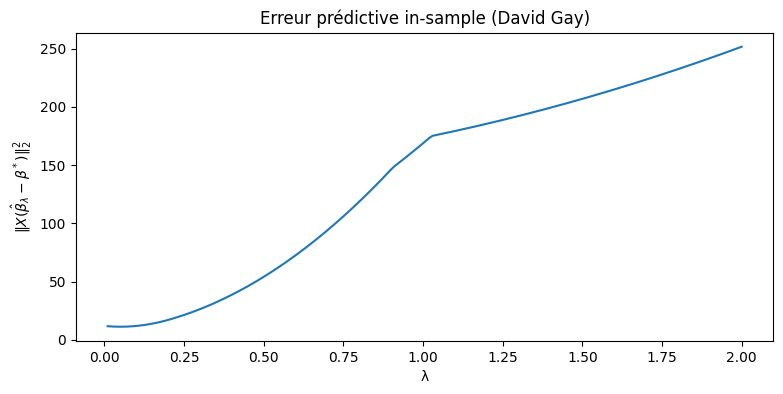

λ optimal (in-sample) = 0.05


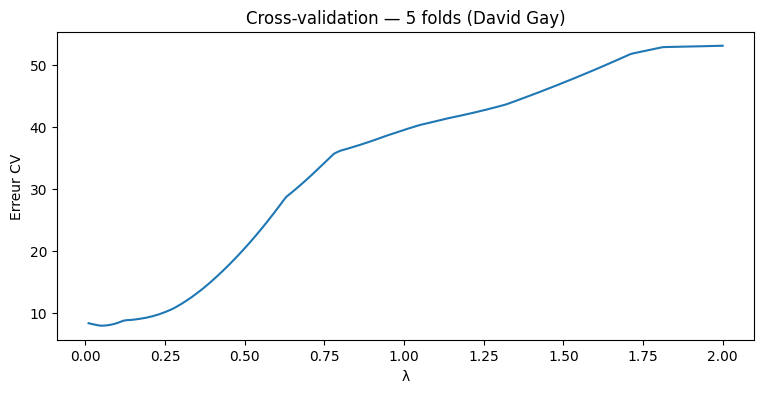

λ optimal (CV) = 0.05
λ optimal (in-sample) = 0.05


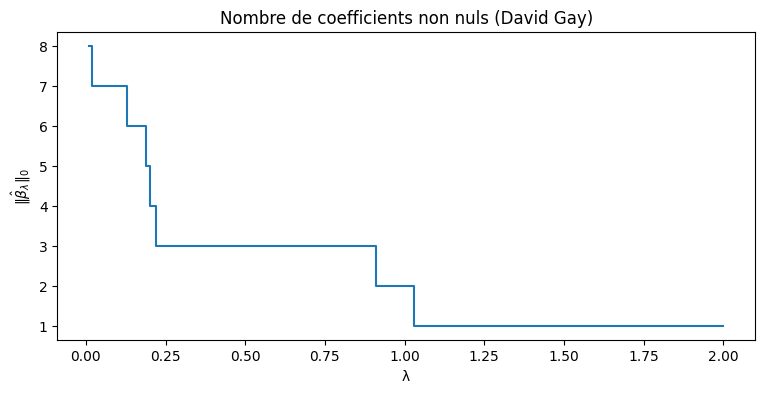

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize


np.random.seed(42)
n_samples = 20
dim = 8
X = np.random.standard_normal((n_samples, dim))
beta_star = np.array([5, 3, 0, 0, 1.5, 0, 0, 0])
eps = np.random.standard_normal(n_samples)
Y = X @ beta_star + eps

lam_grid = np.arange(0.01, 2.01, 0.01)

# Algorithme de David Gay : β_j = β_j^+ - β_j^-, β_j^+,β_j^- ≥ 0
# z = [β^+_1,...,β^+_p, β^-_1,...,β^-_p]  taille 2p
# L1 se linéarise : ||β||_1 = Σ(β_j^+ + β_j^-)

def lasso_gay(X, Y, lam):
    n, p = X.shape

    # Objectif : (1/2n)||Y - X(β^+ - β^-)||² + λ * Σ(β_j^+ + β_j^-)
    def objective(z):
        beta_plus  = z[:p]
        beta_minus = z[p:]
        beta = beta_plus - beta_minus
        return (1 / (2 * n)) * np.linalg.norm(Y - X @ beta)**2 \
               + lam * np.sum(beta_plus + beta_minus)

    def gradient(z):
        beta_plus  = z[:p]
        beta_minus = z[p:]
        beta = beta_plus - beta_minus
        residual = Y - X @ beta
        grad_common = -(1 / n) * X.T @ residual   # = ∂(moindres carrés)/∂β
        # ∂/∂β^+ = grad_common + λ
        # ∂/∂β^- = -grad_common + λ
        return np.concatenate([grad_common + lam, -grad_common + lam])

    # Contraintes : β_j^+ ≥ 0 et β_j^- ≥ 0  (2p bornes)
    bounds = [(0, None)] * (2 * p)

    z0 = np.zeros(2 * p)
    result = minimize(objective, z0, jac=gradient,
                      method="SLSQP", bounds=bounds,
                      options={"ftol": 1e-10, "maxiter": 10000})

    beta_plus  = result.x[:p]
    beta_minus = result.x[p:]
    return beta_plus - beta_minus

# Question 2
err_lam = []

for lam in lam_grid:
    beta_hat = lasso_gay(X, Y, lam)
    err_lam.append(np.linalg.norm(X @ (beta_hat - beta_star))**2)

err_lam    = np.array(err_lam)
lambda_opt = lam_grid[np.argmin(err_lam)]

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, err_lam)
plt.xlabel("λ")
plt.ylabel(r"$\|X(\hat{\beta}_\lambda - \beta^*)\|_2^2$")
plt.title("Erreur prédictive in-sample (David Gay)")
plt.show()

print(f"λ optimal (in-sample) = {lambda_opt:.2f}")

# Question 3
n_folds = 5
m = n_samples // n_folds

sigma = np.random.permutation(n_samples)
X_tilde = X[sigma]
Y_tilde = Y[sigma]

cv_errors = []

for lam in lam_grid:
    err_lambda = []

    for i in range(n_folds):
        val_idx   = np.arange(i * m, (i + 1) * m)
        train_idx = np.concatenate([np.arange(k * m, (k + 1) * m)
                                    for k in range(n_folds) if k != i])

        X_train, X_val = X_tilde[train_idx], X_tilde[val_idx]
        Y_train, Y_val = Y_tilde[train_idx], Y_tilde[val_idx]

        beta_hat = lasso_gay(X_train, Y_train, lam)
        err_lambda.append(np.linalg.norm(X_val @ beta_hat - Y_val)**2)

    cv_errors.append(np.mean(err_lambda))

cv_errors  = np.array(cv_errors)
lambda_cv  = lam_grid[np.argmin(cv_errors)]

plt.figure(figsize=(9, 4))
plt.plot(lam_grid, cv_errors)
plt.xlabel("λ"); plt.ylabel("Erreur CV")
plt.title("Cross-validation — 5 folds (David Gay)")
plt.show()

print(f"λ optimal (CV) = {lambda_cv:.2f}")
print(f"λ optimal (in-sample) = {lambda_opt:.2f}")

# Question 4
beta_l0 = []

for lam in lam_grid:
    beta_hat = lasso_gay(X, Y, lam)
    beta_l0.append(np.sum(np.abs(beta_hat) > 1e-8))

beta_l0 = np.array(beta_l0)

plt.figure(figsize=(9, 4))
plt.step(lam_grid, beta_l0, where='post')
plt.xlabel("λ"); plt.ylabel(r"$\|\hat{\beta}_\lambda\|_0$")
plt.title("Nombre de coefficients non nuls (David Gay)")
plt.show()